# Introduction

Brief look at the data

In [2]:
import pandas as pd

In [3]:
path = "../data/customer_support_tickets_200k.csv"

In [4]:
df = pd.read_csv(path)
df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate


In [19]:
df.columns

Index(['ticket_id', 'customer_name', 'customer_email', 'product', 'category',
       'issue_description', 'resolution_notes', 'priority', 'status',
       'channel', 'region', 'customer_age', 'customer_gender',
       'subscription_type', 'customer_tenure_months', 'previous_tickets',
       'customer_satisfaction_score', 'first_response_time_hours',
       'resolution_time_hours', 'ticket_created_date', 'ticket_resolved_date',
       'escalated', 'sla_breached', 'operating_system', 'browser',
       'payment_method', 'language', 'preferred_contact_time',
       'issue_complexity_score', 'customer_segment'],
      dtype='str')

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ticket_id                    200000 non-null  int64  
 1   customer_name                200000 non-null  str    
 2   customer_email               200000 non-null  str    
 3   product                      200000 non-null  str    
 4   category                     200000 non-null  str    
 5   issue_description            200000 non-null  str    
 6   resolution_notes             200000 non-null  str    
 7   priority                     200000 non-null  str    
 8   status                       200000 non-null  str    
 9   channel                      200000 non-null  str    
 10  region                       200000 non-null  str    
 11  customer_age                 200000 non-null  int64  
 12  customer_gender              200000 non-null  str    
 13  subscripti

In [21]:
df.describe()

,ticket_id,customer_age,customer_tenure_months,previous_tickets,customer_satisfaction_score,first_response_time_hours,resolution_time_hours,issue_complexity_score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,46.469040,30.377675,9.992115,3.001065,36.309180,120.539718,5.501365
std,57735.171256,16.754304,17.326224,6.053142,1.412273,20.654575,68.969143,2.875587
min,1.000000,18.000000,1.000000,0.000000,1.000000,0.500000,1.000000,1.000000
25%,50000.750000,32.000000,15.000000,5.000000,2.000000,18.460000,60.810000,3.000000
50%,100000.500000,46.000000,30.000000,10.000000,3.000000,36.310000,120.450000,6.000000
75%,150000.250000,61.000000,45.000000,15.000000,4.000000,54.220000,180.260000,8.000000
max,200000.000000,75.000000,60.000000,20.000000,5.000000,72.000000,240.000000,10.000000


## EDA approfondie
Objectif: valider la qualité du dataset et préparer la phase RAG (texte source, métadonnées, cibles de filtrage/re-ranking).


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")


In [23]:
# Dimensions, types et mémoire
print(f"Shape: {df.shape}")
print("Types de colonnes:")
print(df.dtypes.value_counts())

mem_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Mémoire estimée: {mem_mb:.2f} MB")


Shape: (200000, 30)
Types de colonnes:
str        22
int64       6
float64     2
Name: count, dtype: int64
Mémoire estimée: 277.34 MB


In [24]:
# Valeurs manquantes (top)
missing = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
    .sort_values("missing_count", ascending=False)
)
missing.head(15)


,missing_count,missing_pct
browser,40023,20.01
ticket_id,0,0.00
customer_email,0,0.00
product,0,0.00
category,0,0.00
customer_name,0,0.00
resolution_notes,0,0.00
priority,0,0.00
status,0,0.00
channel,0,0.00


In [25]:
# Lignes dupliquées
row_dups = df.duplicated().sum()
print(f"Lignes dupliquées complètes: {row_dups}")

# Doublons potentiels par ticket_id
id_dups = df["ticket_id"].duplicated().sum()
print(f"ticket_id dupliqués: {id_dups}")


Lignes dupliquées complètes: 0
ticket_id dupliqués: 0


In [26]:
# Parsing dates + features temporelles
for col in ["ticket_created_date", "ticket_resolved_date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df["resolution_delay_days"] = (df["ticket_resolved_date"] - df["ticket_created_date"]).dt.total_seconds() / 86400

df["created_year"] = df["ticket_created_date"].dt.year
df["created_month"] = df["ticket_created_date"].dt.month

df[["ticket_created_date", "ticket_resolved_date", "resolution_delay_days", "created_year", "created_month"]].head()


,ticket_created_date,ticket_resolved_date,resolution_delay_days,created_year,created_month
0,2023-05-17,2023-05-20,3.0,2023,5
1,2024-01-06,2024-01-19,13.0,2024,1
2,2022-11-30,2022-12-05,5.0,2022,11
3,2024-03-21,2024-04-04,14.0,2024,3
4,2024-08-16,2024-08-24,8.0,2024,8


In [28]:
# Contrôles de cohérence temporelle
invalid_delay = (df["resolution_delay_days"] < 0).sum()
missing_delay = df["resolution_delay_days"].isna().sum()
print(f"Résolution négative (incohérente): {invalid_delay}")
print(f"Résolution manquante: {missing_delay}")

print("Résumé résolution (jours):")
print(df["resolution_delay_days"].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))


Résolution négative (incohérente): 0
Résolution manquante: 0
Résumé résolution (jours):
count    200000.000000
mean          7.008635
std           4.323570
min           0.000000
50%           7.000000
75%          11.000000
90%          13.000000
95%          14.000000
99%          14.000000
max          14.000000
Name: resolution_delay_days, dtype: float64


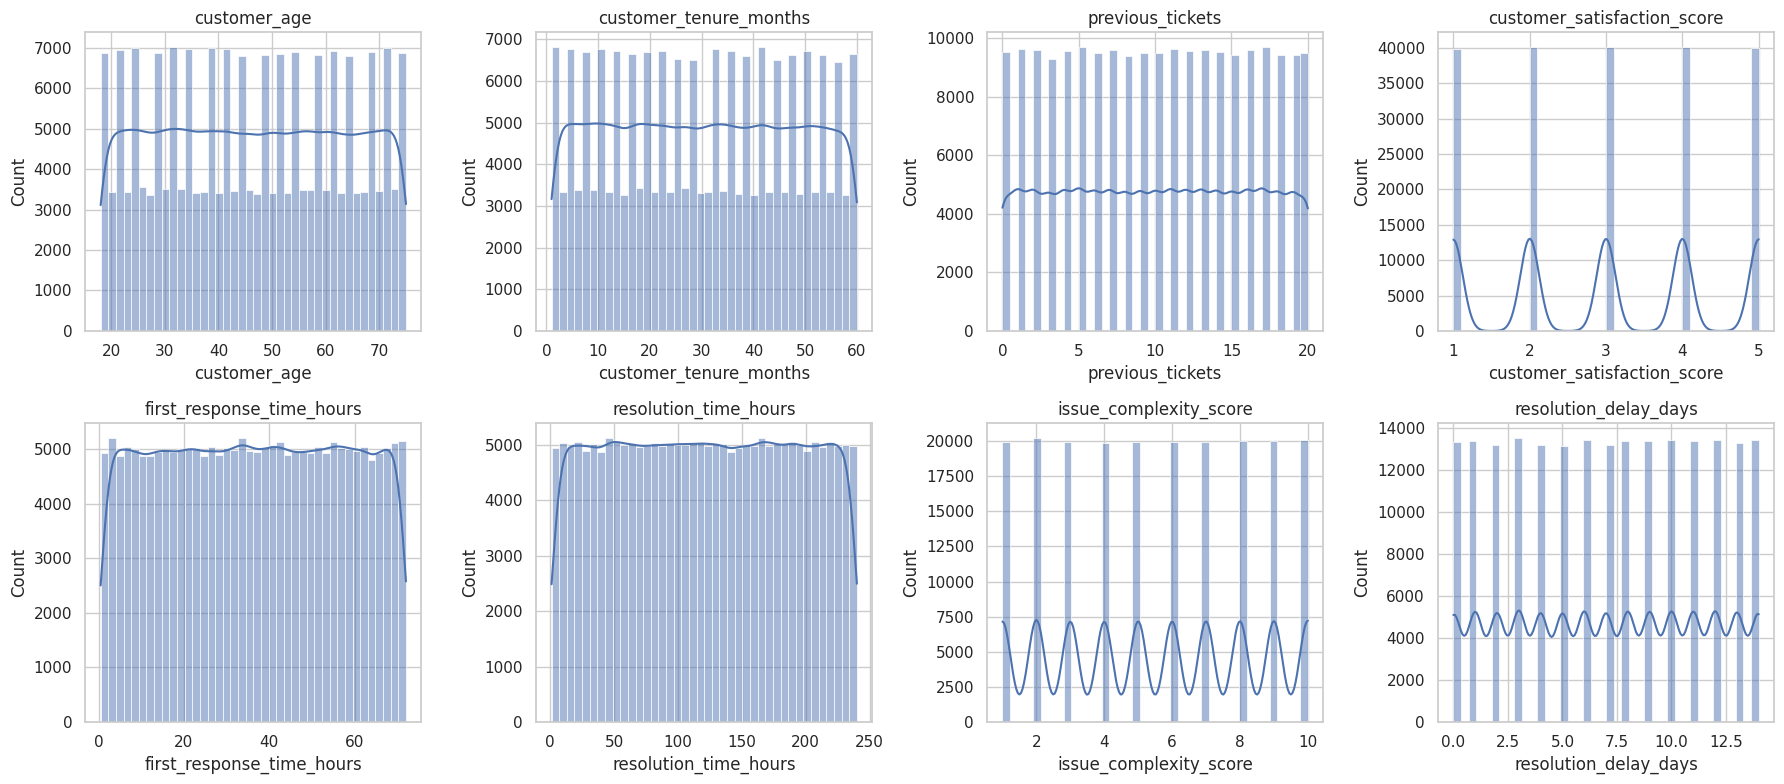

In [29]:
# Distribution des variables numériques
num_cols = [
    "customer_age",
    "customer_tenure_months",
    "previous_tickets",
    "customer_satisfaction_score",
    "first_response_time_hours",
    "resolution_time_hours",
    "issue_complexity_score",
    "resolution_delay_days",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], bins=40)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


In [30]:
# Catégorielles: cardinalité + top modalités
cat_cols = df.select_dtypes(include="object").columns.tolist()

card = (
    pd.DataFrame({
        "column": cat_cols,
        "n_unique": [df[c].nunique(dropna=True) for c in cat_cols]
    })
    .sort_values("n_unique", ascending=False)
)

display(card)

for c in ["product", "category", "priority", "status", "channel", "region", "language", "customer_segment"]:
    print(f"=== {c} ===")
    print(df[c].value_counts(dropna=False).head(10))


/tmp/ipykernel_14359/1198538690.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns.tolist()


,column,n_unique
1,customer_email,191751
0,customer_name,400
2,product,10
3,category,10
4,issue_description,10
5,resolution_notes,10
9,region,6
17,language,6
8,channel,5
16,payment_method,5


=== product ===
product
Billing System          20111
CRM Platform            20097
E-commerce Store        20095
Cloud Storage           20056
Mobile App              20043
Analytics Dashboard     19974
Web Portal              19954
Payment Gateway         19952
Subscription Service    19883
API Service             19835
Name: count, dtype: int64
=== category ===
category
Feature Request              20169
Subscription Cancellation    20096
Performance Issue            20074
Security Concern             20040
Login Issue                  20002
Payment Problem              19997
Bug Report                   19981
Refund Request               19900
Data Sync Issue              19877
Account Suspension           19864
Name: count, dtype: int64
=== priority ===
priority
High      50241
Urgent    50143
Medium    49854
Low       49762
Name: count, dtype: int64
=== status ===
status
In Progress         40065
Closed              40029
Pending Customer    40014
Resolved            39970
Open  

In [16]:
df['customer_email'][df['customer_name'] == 'Patricia Smith']

0         patricia.smith760@outlook.com
297        patricia.smith492@icloud.com
575         patricia.smith977@yahoo.com
748         patricia.smith997@gmail.com
852       patricia.smith210@hotmail.com
                      ...              
197108     patricia.smith649@icloud.com
197291    patricia.smith245@company.com
198665     patricia.smith618@icloud.com
199627    patricia.smith846@company.com
199850      patricia.smith251@gmail.com
Name: customer_email, Length: 490, dtype: str

In [31]:
# Qualité des champs texte (important pour RAG)
text_cols = ["issue_description", "resolution_notes"]

for c in text_cols:
    length_col = c + "_len"
    df[length_col] = df[c].fillna("").str.len()
    print(f"=== {c} ===")
    print(df[length_col].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))
    empty_count = (df[length_col] == 0).sum()
    print(f"Textes vides: {empty_count}")


=== issue_description ===
count    200000.000000
mean         65.923705
std           8.056100
min          55.000000
50%          68.000000
75%          72.000000
90%          79.000000
95%          79.000000
99%          79.000000
max          79.000000
Name: issue_description_len, dtype: float64
Textes vides: 0
=== resolution_notes ===
count    200000.000000
mean         69.016975
std           6.843485
min          60.000000
50%          70.000000
75%          74.000000
90%          80.000000
95%          80.000000
99%          80.000000
max          80.000000
Name: resolution_notes_len, dtype: float64
Textes vides: 0


In [32]:
# Fréquences de catégories dans les descriptions (signal sémantique)
sample_terms = [
    "payment", "login", "crash", "bug", "refund", "subscription", "authentication", "billing"
]

issue_text = df["issue_description"].fillna("").str.lower()
term_freq = {t: issue_text.str.contains(t, regex=False).mean() * 100 for t in sample_terms}
pd.Series(term_freq).sort_values(ascending=False).round(2).to_frame("pct_rows")


,pct_rows
billing,10.12
payment,10.06
authentication,9.99
refund,9.99
subscription,9.96
bug,9.95
crash,9.94
login,0.00


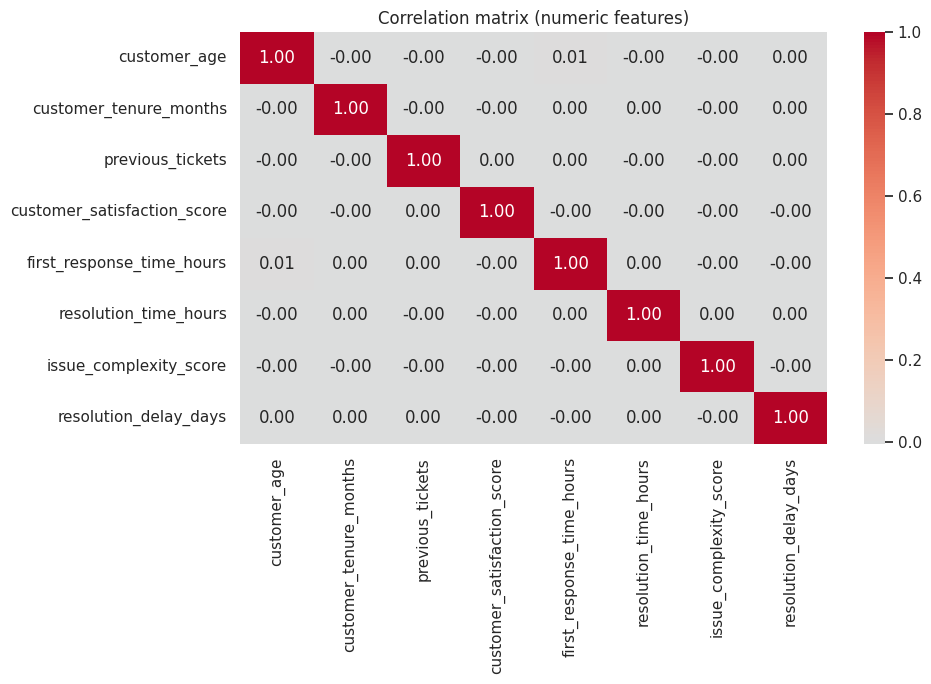

In [33]:
# Corrélations numériques
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()


In [34]:
# Relations utiles: complexité / satisfaction / SLA
pivot_sla = pd.crosstab(df["priority"], df["sla_breached"], normalize="index").round(3)
pivot_status = pd.crosstab(df["status"], df["escalated"], normalize="index").round(3)

print("Part de SLA breached par priorité:")
display(pivot_sla)

print("Part d'escalade par status:")
display(pivot_status)

agg = (
    df.groupby("category", dropna=False)
    .agg(
        tickets=("ticket_id", "count"),
        avg_complexity=("issue_complexity_score", "mean"),
        avg_satisfaction=("customer_satisfaction_score", "mean"),
        avg_resolution_hours=("resolution_time_hours", "mean"),
    )
    .sort_values("tickets", ascending=False)
)
agg.head(15)


Part de SLA breached par priorité:


sla_breached,No,Yes
priority,,
High,0.501,0.499
Low,0.498,0.502
Medium,0.499,0.501
Urgent,0.502,0.498


Part d'escalade par status:


escalated,No,Yes
status,,
Closed,0.497,0.503
In Progress,0.502,0.498
Open,0.493,0.507
Pending Customer,0.498,0.502
Resolved,0.500,0.500


,tickets,avg_complexity,avg_satisfaction,avg_resolution_hours
category,,,,
Feature Request,20169,5.513362,2.996034,120.610610
Subscription Cancellation,20096,5.511943,3.012042,120.543078
Performance Issue,20074,5.514995,2.995467,120.728006
Security Concern,20040,5.467814,2.993513,120.362533
Login Issue,20002,5.506649,2.999000,120.661216
Payment Problem,19997,5.512427,3.007701,120.939464
Bug Report,19981,5.479155,3.000500,120.318886
Refund Request,19900,5.483769,3.010704,119.794275
Data Sync Issue,19877,5.512200,3.008502,121.021393


## Checklist avant RAG
1. Créer un champ `document_text` (concat `issue_description` + `resolution_notes` + métadonnées utiles).
2. Définir les métadonnées de filtrage: `product`, `category`, `priority`, `language`, `region`, `customer_segment`, `status`.
3. Exclure ou pseudonymiser PII (`customer_name`, `customer_email`) avant indexation.
4. Traiter les valeurs manquantes (`browser`, éventuelles dates invalides) et normaliser les catégories.
5. Préparer un jeu d'évaluation retrieval: requêtes types + tickets pertinents attendus.


In [36]:
# Prototype de champ document pour le futur index RAG
meta_cols = ["product", "category", "priority", "status", "channel", "region", "language", "customer_segment"]

def build_document(row):
    meta = " | ".join([f"{c}: {row[c]}" for c in meta_cols])
    return (
        f"Issue: {row['issue_description']}"
        f"Resolution: {row['resolution_notes']}"
        f"Metadata: {meta}"
    )

df["document_text"] = df.apply(build_document, axis=1)
df[["ticket_id", "document_text"]].head(3)


,ticket_id,document_text
0,1,Issue: The payment was deducted from my bank a...
1,2,Issue: I found a bug in the latest update affe...
2,3,Issue: The application crashes whenever I try ...
